In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
from scsims import SIMS

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Load data

In [27]:
adata_luo = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/leo_project/luo_files/Luo2021nature_new_labels.h5ad')
adata_wendering = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/leo_project/wend_files/Wend2024sciadv_two_labels.h5ad')
adata_leo_treg = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/immune-sims/leo_data/fer_cd4_treg_ngs_final.h5ad')
adata_leo_teff = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/immune-sims/leo_data/fer_cd4_teff_ngs_final.h5ad')

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


2. Create the same labels

luo:

In [4]:
adata_luo.obs.head()
unique_cell_types = adata_luo.obs['treg'].unique()
print(unique_cell_types)

['effector', 'naive']
Categories (2, object): ['effector', 'naive']


In [5]:
# update Luo dataset labels in the 'treg' column
adata_luo.obs['treg'] = adata_luo.obs['treg'].replace({
    'effector': 'Teffector',
    'naive': 'Treg'
})
unique_cell_types = adata_luo.obs['treg'].unique()
print(unique_cell_types)

['Teffector', 'Treg']
Categories (2, object): ['Teffector', 'Treg']


In [6]:
cell_type_counts = adata_luo.obs['treg'].value_counts()
print("\nCell type distribution:")
print(cell_type_counts)
adata_luo.n_obs


Cell type distribution:
treg
Treg         3658
Teffector    3333
Name: count, dtype: int64


6991

In [7]:
adata_luo.obs.rename(columns={'treg': 'cell_type'}, inplace=True)

In [32]:
print(adata_luo.var.shape[0])

15874


In [8]:
print(adata_luo.obs.head())

                    cell_type
AAACCTGAGAAACCGC_6  Teffector
AAACCTGAGACACTAA_7  Teffector
AAACCTGAGACAGGCT_7  Teffector
AAACCTGAGACCTTTG_6  Teffector
AAACCTGAGACGCTTT_5  Teffector


save to .h5ad

In [9]:
adata_luo.write('adata_luo_for_harmony.h5ad')

### wend:

In [10]:
print(adata_wendering.obs['treg'].unique())

['Teffector', 'Treg']
Categories (2, object): ['Teffector', 'Treg']


In [31]:
#count genes in var
print(adata_wendering.var.shape[0])

23645


In [11]:
cell_type_counts = adata_wendering.obs['treg'].value_counts()
print("\nCell type distribution:")
print(cell_type_counts)



Cell type distribution:
treg
Teffector    11081
Treg          8305
Name: count, dtype: int64


In [12]:
adata_wendering.obs.rename(columns={'treg': 'cell_type'}, inplace=True)
print(adata_wendering.obs.head())

                          cell_type
CoTP8_ACTTGTTCACAGAGGT-1  Teffector
CoTP8_ACACCCTAGCGTAATA-1       Treg
CoTP2_TTCTCAAAGACCACGA-1       Treg
CoTP8_CTCTAATTCACGATGT-1  Teffector
CoTP4_AAGGCAGAGGTGATAT-1       Treg


check and delete duplicated genes in Wend

In [14]:
print(adata_wendering.var_names.duplicated().sum())  # Check for duplicates in Wendering
adata_wendering = adata_wendering[:, ~adata_wendering.var_names.duplicated()]

10


save to h5

In [16]:
adata_wendering.write('adata_wend_for_harmony.h5ad')

leo data: 
- remove cols, add 'treg' column to both datasets, label 'Treg' for treg set and 'Teff' for teff set

In [17]:
print(adata_leo_teff.obs.columns)
unique = adata_leo_teff.obs['tcell_type'].unique()
print(unique)

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nUMI', 'nGene', 'sample',
       'pMito', 'patient', 'act_tcell', 'tcell_type', 'activation',
       'mito_filter_out', 'numi_out', 'all_out', 'integrated_snn_res.0.1',
       'integrated_snn_res.0.2', 'integrated_snn_res.0.3',
       'integrated_snn_res.0.4', 'integrated_snn_res.0.5',
       'integrated_snn_res.0.6', 'integrated_snn_res.0.7',
       'integrated_snn_res.0.8', 'integrated_snn_res.0.9',
       'integrated_snn_res.1', 'integrated_snn_res.1.1',
       'integrated_snn_res.1.2', 'seurat_clusters', 'scDblFinder.class',
       'garnett_celltypes', 'activation_status', 'Cell', 'Cluster1',
       'Cluster2', 'down_treg', 'up_treg', 'clusters', 'S.Score', 'G2M.Score',
       'Phase', 'treg_score', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2',
       'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5',
       'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8',
       'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1',
       

In [18]:
adata_leo_teff.obs = adata_leo_teff.obs[['tcell_type']]
adata_leo_teff.obs.rename(columns={'tcell_type': 'cell_type'}, inplace=True)
print(adata_leo_teff.obs.columns)
cell_type_counts = adata_leo_teff.obs['cell_type'].count()
print(cell_type_counts)

Index(['cell_type'], dtype='object')
45955


In [19]:
print(adata_leo_treg.obs.columns)
unique = adata_leo_treg.obs['tcell_type'].unique()
print(unique)

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nUMI', 'nGene', 'sample',
       'pMito', 'patient', 'act_tcell', 'tcell_type', 'activation',
       'mito_filter_out', 'numi_out', 'all_out', 'integrated_snn_res.0.1',
       'integrated_snn_res.0.2', 'integrated_snn_res.0.3',
       'integrated_snn_res.0.4', 'integrated_snn_res.0.5',
       'integrated_snn_res.0.6', 'integrated_snn_res.0.7',
       'integrated_snn_res.0.8', 'integrated_snn_res.0.9',
       'integrated_snn_res.1', 'integrated_snn_res.1.1',
       'integrated_snn_res.1.2', 'seurat_clusters', 'scDblFinder.class',
       'garnett_celltypes', 'activation_status', 'Cell', 'Cluster1',
       'Cluster2', 'down_treg', 'up_treg', 'clusters', 'S.Score', 'G2M.Score',
       'Phase', 'treg_score', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2',
       'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5',
       'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8',
       'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1',
       

In [20]:
adata_leo_treg.obs = adata_leo_treg.obs[['tcell_type']]
adata_leo_treg.obs.rename(columns={'tcell_type': 'cell_type'}, inplace=True)
print(adata_leo_treg.obs.columns)
cell_type_counts = adata_leo_treg.obs['cell_type'].count()
print(cell_type_counts)

Index(['cell_type'], dtype='object')
48686


combine leo treg and teff sets

In [21]:
adata_leo_combined = sc.concat([adata_leo_treg, adata_leo_teff], merge='same', label=None)


In [22]:
cell_type_counts = adata_leo_combined.obs['cell_type'].value_counts()
print("\nCell type distribution:")
print(cell_type_counts)
adata_leo_combined.n_obs


Cell type distribution:
cell_type
Treg    48686
Teff    45955
Name: count, dtype: int64


94641

In [23]:
adata_leo_combined.write('adata_leo_combined_for_harmony.h5ad')

for all 3:

In [27]:
#rename
# add prefixes to make indices unique for each dataset
adata_luo.obs_names = [f"Luo_{idx}" for idx in adata_luo.obs_names]
adata_wendering.obs_names = [f"Wendering_{idx}" for idx in adata_wendering.obs_names]
adata_leo_combined.obs_names = [f"Leo_{idx}" for idx in adata_leo_combined.obs_names]


In [29]:
# Identify duplicate indices
print(adata_luo.obs_names.duplicated().sum())
print(adata_wendering.obs_names.duplicated().sum())
print(adata_leo_combined.obs_names.duplicated().sum())

# # Optionally remove duplicates (if any exist)
# adata_luo = adata_luo[~adata_luo.obs_names.duplicated()]
# adata_wendering = adata_wendering[~adata_wendering.obs_names.duplicated()]
# adata_leo_combined = adata_leo_combined[~adata_leo_combined.obs_names.duplicated()]


0
0
0


In [30]:
print(adata_luo.var_names.duplicated().sum())  # Check for duplicates in Luo
print(adata_wendering.var_names.duplicated().sum())  # Check for duplicates in Wendering
print(adata_leo_combined.var_names.duplicated().sum())  # Check for duplicates in Leo


0
10
0


remove 10 wend duplicate genes

In [31]:
adata_wendering = adata_wendering[:, ~adata_wendering.var_names.duplicated()]

In [32]:
print(adata_luo.var_names.duplicated().sum())  # Check for duplicates in Luo
print(adata_wendering.var_names.duplicated().sum())  # Check for duplicates in Wendering
print(adata_leo_combined.var_names.duplicated().sum())  # Check for duplicates in Leo

0
0
0


only common genes:

In [33]:
common_genes = list(
    set(adata_luo.var_names)
    & set(adata_wendering.var_names)
    & set(adata_leo_combined.var_names)
)

adata_luo = adata_luo[:, common_genes]
adata_wendering = adata_wendering[:, common_genes]
adata_leo_combined = adata_leo_combined[:, common_genes]
print(len(common_genes))

2693


In [1]:
print(f"Luo shape: {adata_luo.shape}")
print(f"Wendering shape: {adata_wendering.shape}")
print(f"Leo combined shape: {adata_leo_combined.shape}")


NameError: name 'adata_luo' is not defined

Next part needs to be done in separate script and run on NRP

In [34]:
# # downsample Leo's dataset (because it has WAY more cells than the others)
# downsample_size = 20000  # target size for downsampling
# np.random.seed(42)  # reproducibility
# sampled_indices = np.random.choice(adata_leo_combined.n_obs, size=downsample_size, replace=False)
# adata_leo_combined = adata_leo_combined[sampled_indices, :]

# print("After downsampling Leo:")
# print(f"Leo combined dataset: {adata_leo_combined.n_obs} cells, {adata_leo_combined.n_vars} genes")

# # normalize datasets
# sc.pp.normalize_total(adata_luo, target_sum=1e4)
# sc.pp.log1p(adata_luo)

# sc.pp.normalize_total(adata_wendering, target_sum=1e4)
# sc.pp.log1p(adata_wendering)

# sc.pp.normalize_total(adata_leo_combined, target_sum=1e4)
# sc.pp.log1p(adata_leo_combined)

# # align genes across datasets
# common_genes = list(
#     set(adata_luo.var_names)
#     & set(adata_wendering.var_names)
#     & set(adata_leo_combined.var_names)
# )
# adata_luo = adata_luo[:, common_genes]
# adata_wendering = adata_wendering[:, common_genes]
# adata_leo_combined = adata_leo_combined[:, common_genes]

# print("After keeping only common genes:")
# print(f"Luo dataset: {adata_luo.n_obs} cells, {adata_luo.n_vars} genes")
# print(f"Wendering dataset: {adata_wendering.n_obs} cells, {adata_wendering.n_vars} genes")
# print(f"Leo combined dataset: {adata_leo_combined.n_obs} cells, {adata_leo_combined.n_vars} genes")

# # handle NaNs if present
# print("Checking for NaNs in the dataset...")
# def check_for_nans_in_sparse_matrix(matrix):
#     if scipy.sparse.issparse(matrix):
#         return np.isnan(matrix.data).sum()  # check NaNs in the sparse matrix data
#     else:
#         return np.isnan(matrix).sum()  # for dense matrices
# print(check_for_nans_in_sparse_matrix(adata_luo.X), "NaNs in Luo")
# print(check_for_nans_in_sparse_matrix(adata_wendering.X), "NaNs in Wendering")
# print(check_for_nans_in_sparse_matrix(adata_leo_combined.X), "NaNs in Leo")

# # impute missing values using mean strategy
# imputer = SimpleImputer(strategy="mean")
# adata_luo.X = imputer.fit_transform(adata_luo.X)
# adata_wendering.X = imputer.fit_transform(adata_wendering.X)
# adata_leo_combined.X = imputer.fit_transform(adata_leo_combined.X)

# # concatenate datasets
# adata_all = sc.concat(
#     [adata_luo, adata_wendering, adata_leo_combined],
#     label="batch",  # add batch column
#     keys=["Luo", "Wendering", "Leo"],  # assign batch names
#     merge="same"  
# )
# print(f"Combined dataset: {adata_all.n_obs} cells, {adata_all.n_vars} genes")

# # PCA
# sc.pp.pca(adata_all, n_comps=50)

# # run Harmony for batch correction
# harmony_out = hm.run_harmony(adata_all.obsm['X_pca'], adata_all.obs, 'batch')
# adata_all.obsm['X_pca_harmony'] = harmony_out.Z_corr.T

# # save the processed dataset locally
# adata_all.write("adata_all.h5ad")

# # upload the processed dataset back to AWS
# upload_files("", "adata_all.h5ad")
# print("Job completed and results uploaded to AWS!")


In [24]:
print(f"Luo cells: {adata_luo.n_obs}")
print(f"Wendering cells: {adata_wendering.n_obs}")
print(f"Leo cells: {adata_leo_combined.n_obs}")


Luo cells: 6991
Wendering cells: 19386
Leo cells: 94641


investigate `adata_all` from s3

In [2]:
adata_all = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/immune-sims/adata_all.h5ad')

# Basic information about the data
print(adata_all)

# Check the number of observations (cells) and variables (genes)
print(f"Number of observations (cells): {adata_all.n_obs}")
print(f"Number of variables (genes): {adata_all.n_vars}")

# View the first few observations (cells)
print(adata_all.obs.head())

# View the first few variables (genes)
print(adata_all.var.head())

AnnData object with n_obs × n_vars = 46377 × 2693
    obs: 'cell_type', 'batch'
    uns: 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
Number of observations (cells): 46377
Number of variables (genes): 2693
                        cell_type batch
Luo_AAACCTGAGAAACCGC_6  Teffector   Luo
Luo_AAACCTGAGACACTAA_7  Teffector   Luo
Luo_AAACCTGAGACAGGCT_7  Teffector   Luo
Luo_AAACCTGAGACCTTTG_6  Teffector   Luo
Luo_AAACCTGAGACGCTTT_5  Teffector   Luo
Empty DataFrame
Columns: []
Index: [CPNE3, BCL9, BAZ1B, BATF3, CYP2E1]


In [5]:
# Check PCA embeddings
print(adata_all.obsm['X_pca'].shape)

# Check Harmony embeddings
print(adata_all.obsm['X_pca_harmony'].shape)

(46377, 50)
(46377, 50)


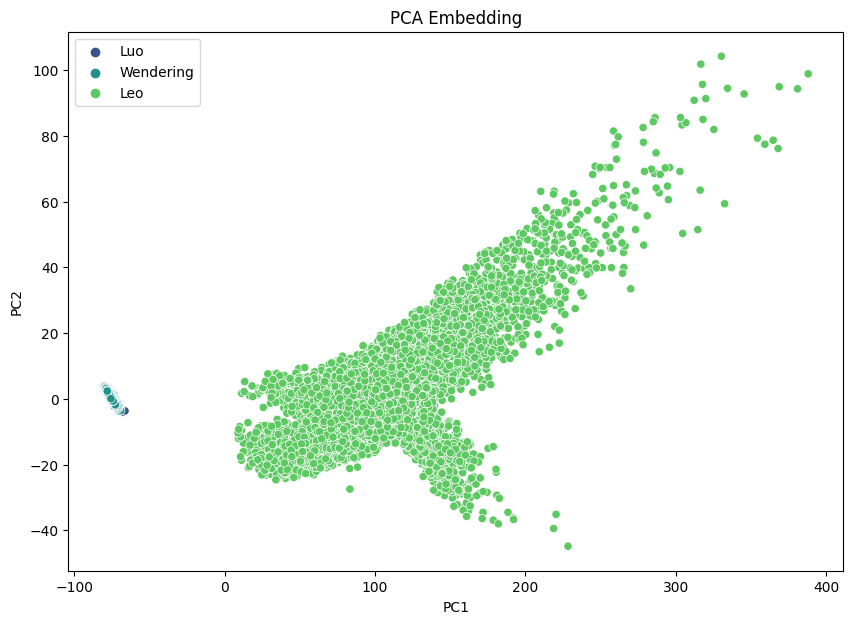

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the PCA embeddings
pca_embedding = adata_all.obsm['X_pca']

# Plot the first two principal components (PC1 vs PC2)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_embedding[:, 0], y=pca_embedding[:, 1], hue=adata_all.obs['batch'], palette="viridis")
plt.title('PCA Embedding')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


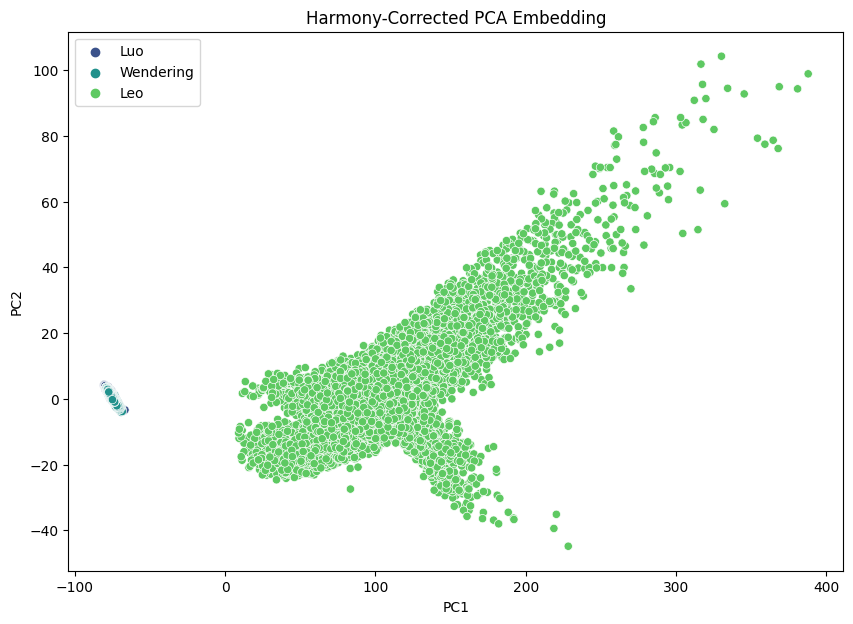

In [7]:
# Get the Harmony embeddings
harmony_embedding = adata_all.obsm['X_pca_harmony']

# Plot the first two Harmony-corrected principal components (PC1 vs PC2)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=harmony_embedding[:, 0], y=harmony_embedding[:, 1], hue=adata_all.obs['batch'], palette="viridis")
plt.title('Harmony-Corrected PCA Embedding')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


In [8]:
# Verify that Harmony has been applied correctly
print(adata_all.obsm['X_pca_harmony'])


[[-7.63091278e+01  9.28977549e-01 -3.90837379e-02 ... -9.11623776e-01
   1.37061584e+00  9.02079523e-01]
 [-7.80998688e+01  2.47983766e+00 -4.75689381e-01 ... -1.56359148e+00
   8.69827867e-01 -2.80548055e-02]
 [-7.62330322e+01  7.75395513e-01  6.70602322e-02 ... -4.38961357e-01
   3.10556948e-01 -5.66682458e-01]
 ...
 [ 1.08455505e+02 -6.47952223e+00  2.43233228e+00 ...  6.18517041e-01
   3.82096589e-01 -1.63484120e+00]
 [ 1.07609833e+02  3.16905284e+00 -5.49037600e+00 ... -1.95132720e+00
   1.42659217e-01 -1.83791935e-01]
 [ 9.38185730e+01  1.19285583e+01 -8.26110840e+00 ...  1.90016365e+00
  -1.70668983e+00  1.98800400e-01]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


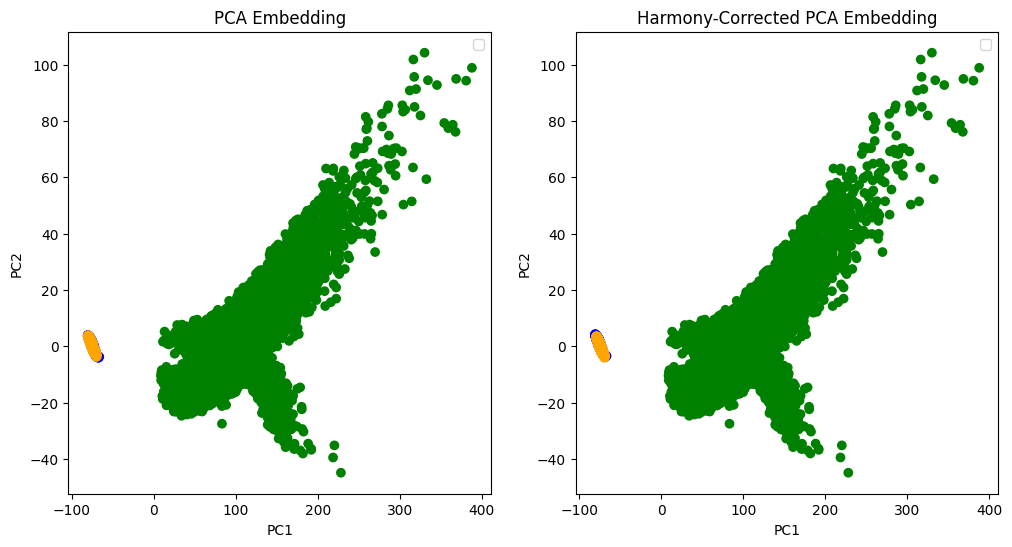

In [23]:
import matplotlib.pyplot as plt

# PCA embedding
pca_embedding = adata_all.obsm['X_pca']
# Harmony-corrected PCA embedding
harmony_embedding = adata_all.obsm['X_pca_harmony']

# Plot both
plt.figure(figsize=(12, 6))

# Plot PCA embedding
plt.subplot(1, 2, 1)
plt.scatter(pca_embedding[:, 0], pca_embedding[:, 1], c=adata_all.obs['batch'].map({'Luo': 'blue', 'Wendering': 'orange', 'Leo': 'green'}))
plt.title("PCA Embedding")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

# Plot Harmony-corrected PCA embedding
plt.subplot(1, 2, 2)
plt.scatter(harmony_embedding[:, 0], harmony_embedding[:, 1], c=adata_all.obs['batch'].map({'Luo': 'blue', 'Wendering': 'orange', 'Leo': 'green'}))
plt.title("Harmony-Corrected PCA Embedding")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.show()


In [24]:
diff = adata_all.obsm['X_pca_harmony'] - adata_all.obsm['X_pca']
print(np.max(np.abs(diff)))


1.7802851


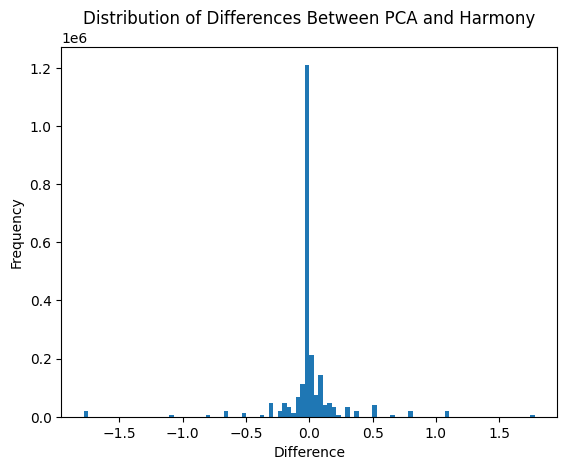

In [25]:
import matplotlib.pyplot as plt
plt.hist(diff.flatten(), bins=100)
plt.title("Distribution of Differences Between PCA and Harmony")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()


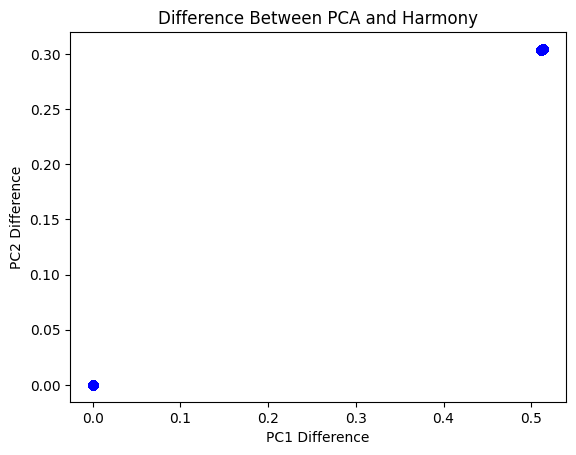

In [26]:
# Calculate the difference
diff = adata_all.obsm['X_pca_harmony'] - adata_all.obsm['X_pca']
diff_abs = np.abs(diff)

# Visualize the difference on PCA and Harmony plots
plt.scatter(diff_abs[:, 0], diff_abs[:, 1], c='blue', alpha=0.5)
plt.xlabel('PC1 Difference')
plt.ylabel('PC2 Difference')
plt.title('Difference Between PCA and Harmony')
plt.show()


## problems: 

- mismatch in cell/gene #s
    - leo combined dataset has 94641 cells and only 3000 genes --> downsampled cells 
    - wend dataset has 19386 cells and 23645 genes
    - luo has 6991 cells and 15874 genes

- only ~2700 overlapping genes 
- no idea how leo's data is preprocessed
- wend and luo models generalized terribly on each other
- can't do explainability for leo data because there aren't enough genes

In [43]:
from scipy.sparse import issparse
import numpy as np
import scanpy as sc

# Load dataset
adata_leo_teff = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/immune-sims/leo_data/fer_cd4_teff_ngs_final.h5ad')

# Check for zero-variance genes
gene_variances = adata_leo_teff.X.var(axis=0)
print("Number of zero-variance genes:", (gene_variances == 0).sum())

# Filter out zero-variance genes
non_zero_var_genes = gene_variances > 0
adata_leo_teff = adata_leo_teff[:, non_zero_var_genes]

# Convert to dense if sparse
if issparse(adata_leo_teff.X):
    adata_leo_teff.X = adata_leo_teff.X.toarray()

# Check for NaNs before scaling
print("Checking for NaNs before scaling:", np.isnan(adata_leo_teff.X).sum())

# Apply scaling
sc.pp.scale(adata_leo_teff)

# Check for NaNs after scaling
print("Checking for NaNs after scaling:", np.isnan(adata_leo_teff.X).sum())


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


Number of zero-variance genes: 57
Checking for NaNs before scaling: 0


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Checking for NaNs after scaling: 0


In [40]:
a= "hi"
b = "bye"
# print(a)
# print(a, end= " and ")
print(a, "and", b, sep=" , ")

hi , and , bye


In [2]:
import scanpy as sc
# import harmonypy as hm
# from s3_utils import download_single_file, upload_files
import numpy as np
import scipy.sparse
from sklearn.impute import SimpleImputer
import pandas as pd

adata_leo = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/immune-sims/leo_data/fer_cd4_teff_ngs_final.h5ad')

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [7]:
#WEND
adata = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/immune-sims/adata_wend_for_harmony.h5ad')
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
if not isinstance(adata.X, np.ndarray):
        adata.X = adata.X.toarray()
sc.pp.scale(adata)
zero_variance_genes = np.var(adata.X, axis=0) == 0
if np.any(zero_variance_genes):
    adata = adata[:, ~zero_variance_genes]
    # Clip extreme outliers post-scaling
adata.X = np.clip(adata.X, -10, 10)

print(f"range: {adata.X.min()}, max value: {adata.X.max()}")

range: -9.656620025634766, max value: 10.0


In [8]:
#LUO
adata = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/immune-sims/adata_luo_for_harmony.h5ad')
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
if not isinstance(adata.X, np.ndarray):
        adata.X = adata.X.toarray()
sc.pp.scale(adata)
zero_variance_genes = np.var(adata.X, axis=0) == 0
if np.any(zero_variance_genes):
    adata = adata[:, ~zero_variance_genes]
    # Clip extreme outliers post-scaling
adata.X = np.clip(adata.X, -10, 10)

print(f"range: {adata.X.min()}, max value: {adata.X.max()}")

range: -9.664708137512207, max value: 10.0


In [5]:
#LEO
def preprocess_dataset(adata, dataset_name):
    print(f"Preprocessing {dataset_name}...")
    if not isinstance(adata.X, np.ndarray):
        adata.X = adata.X.toarray()

    print(f"Number of NaNs: {np.isnan(adata.X).sum()}")

    # Step 1: Ensure unique variable names
    adata.var_names_make_unique()
    print("Step 1: Ensured unique variable names.")

    # Step 2: Filter cells and genes
    sc.pp.filter_cells(adata, min_genes=100)
    sc.pp.filter_genes(adata, min_cells=3)
    print(f"Step 2-3: Filtered dataset shape: {adata.shape}")
    print(f"Number of NaNs: {np.isnan(adata.X).sum()}")

    print("negative values before normalization: ", (adata.X < 0).sum())
    # Step 4: Normalize total counts
    # sc.pp.normalize_total(adata)
    print("Step 4: Normalized total counts.")
    print(f"Number of NaNs: {np.isnan(adata.X).sum()}")

    # Step 5: Logarithmize the data
    # sc.pp.log1p(adata)
    print("Step 5: Logarithmized the data.")
    print(f"Number of NaNs: {np.isnan(adata.X).sum()}")

    # Step 6: Convert sparse to dense if necessary
    if not isinstance(adata.X, np.ndarray):
        adata.X = adata.X.toarray()
        print("Step 6: Converted sparse matrix to dense format.")

    # Step 7: Check for invalid values and replace them
    print("Step 7: Checking for invalid values in the data matrix...")
    if np.any(np.isnan(adata.X)) or np.any(np.isinf(adata.X)):
        print(f"Invalid values detected!")
        print(f"Number of NaNs: {np.isnan(adata.X).sum()}")
        print(f"Number of Infs: {np.isinf(adata.X).sum()}")
        
        # Replace NaNs with 0 and Infs with large finite numbers
        adata.X[np.isnan(adata.X)] = 0
        adata.X[np.isinf(adata.X)] = np.nanmax(adata.X[np.isfinite(adata.X)])
        print("Replaced NaNs with 0 and Infs with the maximum finite value.")

    # Step 8: Scale the data
    # sc.pp.scale(adata)
    print("Step 8: Scaled the data.")

    # Step 9: Remove zero-variance genes
    zero_variance_genes = np.var(adata.X, axis=0) == 0
    if np.any(zero_variance_genes):
        print(f"Number of zero-variance genes: {zero_variance_genes.sum()}")
        adata = adata[:, ~zero_variance_genes]
        print(f"Dataset shape after removing zero-variance genes: {adata.shape}")

    # Step 10: Compute Highly Variable Genes (HVGs)
    try:
        print("Step 9: Computing Highly Variable Genes...")
        sc.pp.highly_variable_genes(adata, n_top_genes=2000)
        print("Highly variable genes computed successfully.")
        print(f"Number of HVGs selected: {adata.var['highly_variable'].sum()}")
    except Exception as e:
        print(f"Error during HVG computation: {e}")
        return adata

    # Step 11: Subset the dataset to include only HVGs
    adata = adata[:, adata.var["highly_variable"]].copy()
    print(f"Dataset shape after HVG selection: {adata.shape}")

    print(f"Preprocessing completed for {dataset_name}.")
    return adata

adata_leo_teff = adata_leo.copy()
print("Before combining/altering:")

print(f"Leo combined dataset: {adata_leo_teff.n_obs} cells, {adata_leo_teff.n_vars} genes")
# Preprocess datasets

print("Preprocessing Leo: ")
adata_leo_teff = preprocess_dataset(adata_leo_teff, "Leo")

# Downsample Leo after preprocessing
print("Downsampling Leo's dataset...")
downsample_size = 20000
np.random.seed(42)
sampled_indices = np.random.choice(adata_leo_teff.n_obs, size=downsample_size, replace=False)
adata_leo_teff = adata_leo_teff[sampled_indices, :]
print(f"After downsampling - Leo: {adata_leo_teff.n_obs} cells, {adata_leo_teff.n_vars} genes")




Before combining/altering:
Leo combined dataset: 45955 cells, 3136 genes
Preprocessing Leo: 
Preprocessing Leo...
Number of NaNs: 0
Step 1: Ensured unique variable names.
Step 2-3: Filtered dataset shape: (45955, 3079)
Number of NaNs: 0
negative values before normalization:  111289438
Step 4: Normalized total counts.
Number of NaNs: 0
Step 5: Logarithmized the data.
Number of NaNs: 0
Step 7: Checking for invalid values in the data matrix...
Step 8: Scaled the data.
Step 9: Computing Highly Variable Genes...
Highly variable genes computed successfully.
Number of HVGs selected: 2000
Dataset shape after HVG selection: (45955, 2000)
Preprocessing completed for Leo.
Downsampling Leo's dataset...
After downsampling - Leo: 20000 cells, 2000 genes


In [4]:
print(f"Leo's min value: {adata_leo.X.min()}, max value: {adata_leo.X.max()}")


Leo's min value: -11.598179405431704, max value: 10.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


AnnData object with n_obs × n_vars = 46377 × 2574
    obs: 'cell_type', 'n_genes', 'batch'
    uns: 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
Number of observations (cells): 46377
Number of variables (genes): 2574
                        cell_type  n_genes batch
Luo_AAACCTGAGAAACCGC_6  Teffector     1095   Luo
Luo_AAACCTGAGACACTAA_7  Teffector      970   Luo
Luo_AAACCTGAGACAGGCT_7  Teffector     1156   Luo
Luo_AAACCTGAGACCTTTG_6  Teffector      652   Luo
Luo_AAACCTGAGACGCTTT_5  Teffector     1116   Luo
Empty DataFrame
Columns: []
Index: [FZD6, TIGD1, PITHD1, TUBGCP4, MBNL3]


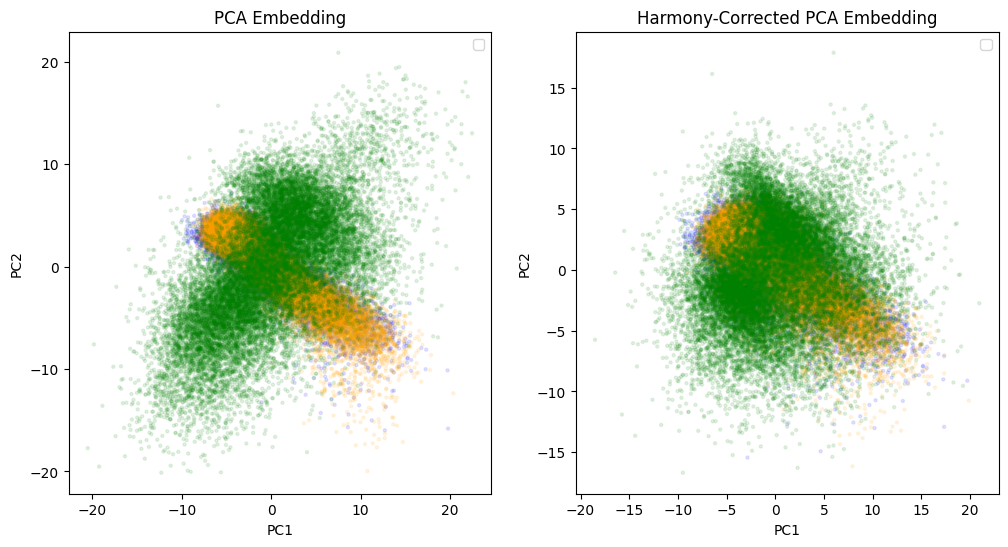

In [14]:
import matplotlib.pyplot as plt

adata_all = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/immune-sims/adata_all_adjusted.h5ad')

# Basic information about the data
print(adata_all)

# Check the number of observations (cells) and variables (genes)
print(f"Number of observations (cells): {adata_all.n_obs}")
print(f"Number of variables (genes): {adata_all.n_vars}")

# View the first few observations (cells)
print(adata_all.obs.head())

# View the first few variables (genes)
print(adata_all.var.head())

# PCA embedding
pca_embedding = adata_all.obsm['X_pca']
# Harmony-corrected PCA embedding
harmony_embedding = adata_all.obsm['X_pca_harmony']

# Plot both
plt.figure(figsize=(12, 6))

# Plot PCA embedding
plt.subplot(1, 2, 1)
plt.scatter(pca_embedding[:, 0], pca_embedding[:, 1], c=adata_all.obs['batch'].map({'Luo': 'blue', 'Wendering': 'orange', 'Leo': 'green'}),alpha=0.1, s=5)
plt.title("PCA Embedding")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

# Plot Harmony-corrected PCA embedding
plt.subplot(1, 2, 2)
plt.scatter(harmony_embedding[:, 0], harmony_embedding[:, 1], c=adata_all.obs['batch'].map({'Luo': 'blue', 'Wendering': 'orange', 'Leo': 'green'}), alpha=0.1, s=5)
plt.title("Harmony-Corrected PCA Embedding")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.show()


In [16]:
import harmonypy as hm
# load datasets
adata_luo = sc.read_h5ad("/Users/zoezabetian/Desktop/M-R-lab/immune-sims/adata_luo_for_harmony.h5ad")
adata_wendering = sc.read_h5ad("/Users/zoezabetian/Desktop/M-R-lab/immune-sims/adata_wend_for_harmony.h5ad")

# add unique prefixes to observation names
adata_luo.obs_names = [f"Luo_{idx}" for idx in adata_luo.obs_names]
adata_wendering.obs_names = [f"Wendering_{idx}" for idx in adata_wendering.obs_names]
# adata_leo_combined.obs_names = [f"Leo_{idx}" for idx in adata_leo_combined.obs_names]

print("Preprocessing Luo...")
sc.pp.filter_cells(adata_luo, min_genes=100)
sc.pp.filter_genes(adata_luo, min_cells=3)
adata_luo.var_names_make_unique()
sc.pp.normalize_total(adata_luo)
sc.pp.log1p(adata_luo)
if not isinstance(adata_luo.X, np.ndarray):
        adata_luo.X = adata_luo.X.toarray()
sc.pp.scale(adata_luo)
zero_variance_genes = np.var(adata_luo.X, axis=0) == 0
if np.any(zero_variance_genes):
    adata_luo = adata_luo[:, ~zero_variance_genes]
adata_luo.X = np.clip(adata_luo.X, -10, 10)
# sc.pp.highly_variable_genes(adata_luo, n_top_genes=2000)
# adata_luo = adata_luo[:, adata_luo.var["highly_variable"]].copy()
zero_variance_genes = np.var(adata_luo.X, axis=0) == 0
if np.any(zero_variance_genes):
    adata_luo = adata_luo[:, ~zero_variance_genes]
print(f"Preprocessed Luo: {adata_luo.n_obs} cells, {adata_luo.n_vars} genes")

print("Preprocessing Wend...")
sc.pp.filter_cells(adata_wendering, min_genes=100)
sc.pp.filter_genes(adata_wendering, min_cells=3)
adata_wendering.var_names_make_unique()
sc.pp.normalize_total(adata_wendering)
sc.pp.log1p(adata_wendering)
if not isinstance(adata_wendering.X, np.ndarray):
        adata_wendering.X = adata_wendering.X.toarray()
sc.pp.scale(adata_wendering)
zero_variance_genes = np.var(adata_wendering.X, axis=0) == 0
if np.any(zero_variance_genes):
    adata_wendering = adata_wendering[:, ~zero_variance_genes]
adata_wendering.X = np.clip(adata_wendering.X, -10, 10)
# sc.pp.highly_variable_genes(adata_wendering, n_top_genes=2000)
# adata_wendering = adata_wendering[:, adata_wendering.var["highly_variable"]].copy()
zero_variance_genes = np.var(adata_wendering.X, axis=0) == 0
if np.any(zero_variance_genes):
    adata_wendering = adata_wendering[:, ~zero_variance_genes]
print(f"Preprocessed Wend: {adata_wendering.n_obs} cells, {adata_wendering.n_vars} genes")


#  concatenate datasets
print("Aligning and concatenating datasets...")
common_genes = list(
    set(adata_luo.var_names) &
    set(adata_wendering.var_names))

print(f"Common genes: {len(common_genes)}")

adata_luo = adata_luo[:, common_genes].copy()
adata_wendering = adata_wendering[:, common_genes].copy()

adata_all = sc.concat(
    [adata_luo, adata_wendering],
    label="batch",
    keys=["Luo", "Wendering"],
    merge="same"
)

print(f"Final concatenated dataset: {adata_all.n_obs} cells, {adata_all.n_vars} genes")

# PCA
sc.pp.pca(adata_all, n_comps=50)

# run Harmony for batch correction
harmony_out = hm.run_harmony(adata_all.obsm['X_pca'], adata_all.obs, 'batch')
adata_all.obsm['X_pca_harmony'] = harmony_out.Z_corr.T

# save the processed dataset locally
adata_all.write("models_only_harmoized.h5ad")

Preprocessing Luo...
Preprocessed Luo: 6991 cells, 14628 genes
Preprocessing Wend...
Preprocessed Wend: 19386 cells, 14361 genes
Aligning and concatenating datasets...
Common genes: 11972
Final concatenated dataset: 26377 cells, 11972 genes


2025-01-30 09:25:42,532 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-30 09:25:53,161 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-30 09:25:53,238 - harmonypy - INFO - Iteration 1 of 10
2025-01-30 09:25:58,367 - harmonypy - INFO - Iteration 2 of 10
2025-01-30 09:26:03,574 - harmonypy - INFO - Converged after 2 iterations


AnnData object with n_obs × n_vars = 26377 × 11972
    obs: 'cell_type', 'n_genes', 'batch'
    uns: 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
Number of observations (cells): 26377
Number of variables (genes): 11972
                        cell_type  n_genes batch
Luo_AAACCTGAGAAACCGC_6  Teffector     1095   Luo
Luo_AAACCTGAGACACTAA_7  Teffector      970   Luo
Luo_AAACCTGAGACAGGCT_7  Teffector     1156   Luo
Luo_AAACCTGAGACCTTTG_6  Teffector      652   Luo
Luo_AAACCTGAGACGCTTT_5  Teffector     1116   Luo
Empty DataFrame
Columns: []
Index: [PIN4, TEX14, TMCO6, XXYLT1-AS2, PPDPF]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


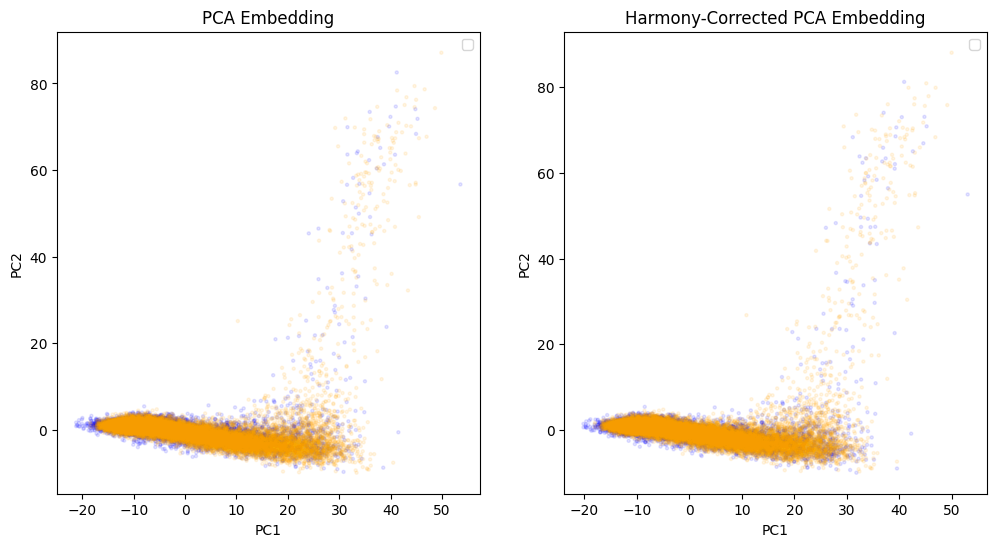

In [17]:
import matplotlib.pyplot as plt

adata_all = sc.read_h5ad('/Users/zoezabetian/Desktop/M-R-lab/capstone/models_only_harmoized.h5ad')

# Basic information about the data
print(adata_all)

# Check the number of observations (cells) and variables (genes)
print(f"Number of observations (cells): {adata_all.n_obs}")
print(f"Number of variables (genes): {adata_all.n_vars}")

# View the first few observations (cells)
print(adata_all.obs.head())

# View the first few variables (genes)
print(adata_all.var.head())

# PCA embedding
pca_embedding = adata_all.obsm['X_pca']
# Harmony-corrected PCA embedding
harmony_embedding = adata_all.obsm['X_pca_harmony']

# Plot both
plt.figure(figsize=(12, 6))

# Plot PCA embedding
plt.subplot(1, 2, 1)
plt.scatter(pca_embedding[:, 0], pca_embedding[:, 1], c=adata_all.obs['batch'].map({'Luo': 'blue', 'Wendering': 'orange', 'Leo': 'green'}),alpha=0.1, s=5)
plt.title("PCA Embedding")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

# Plot Harmony-corrected PCA embedding
plt.subplot(1, 2, 2)
plt.scatter(harmony_embedding[:, 0], harmony_embedding[:, 1], c=adata_all.obs['batch'].map({'Luo': 'blue', 'Wendering': 'orange', 'Leo': 'green'}), alpha=0.1, s=5)
plt.title("Harmony-Corrected PCA Embedding")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.show()
